2023


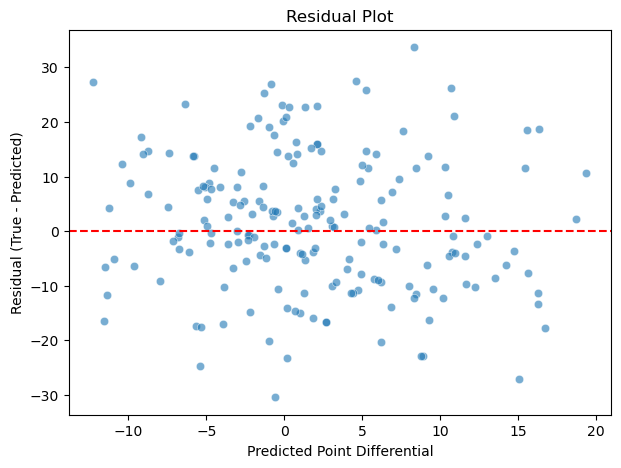

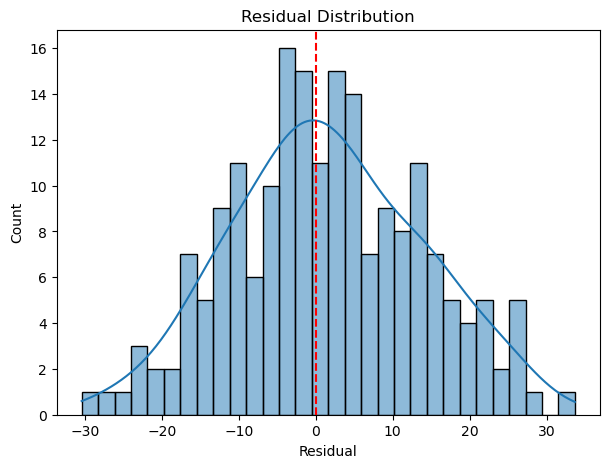

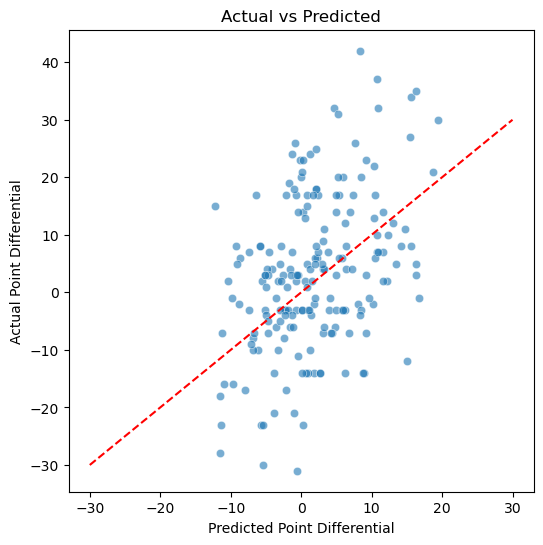

2024


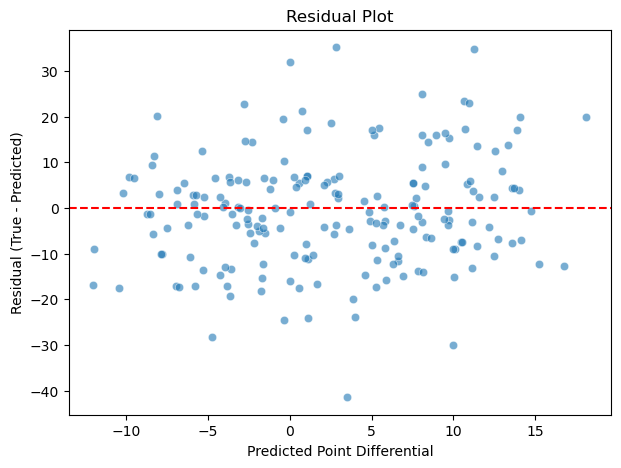

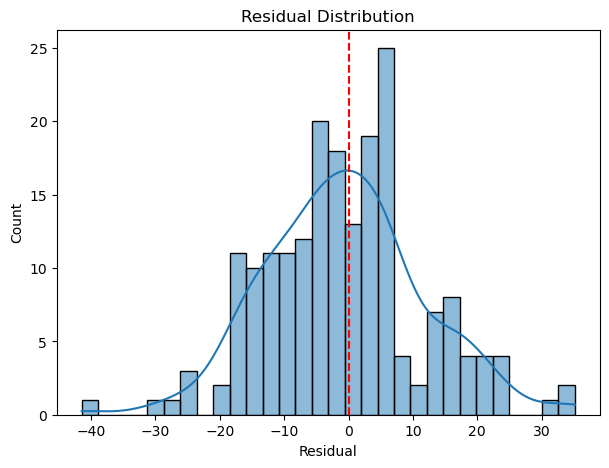

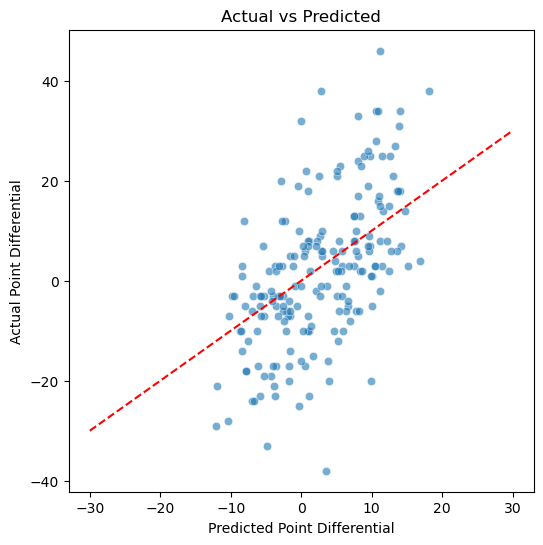

2025


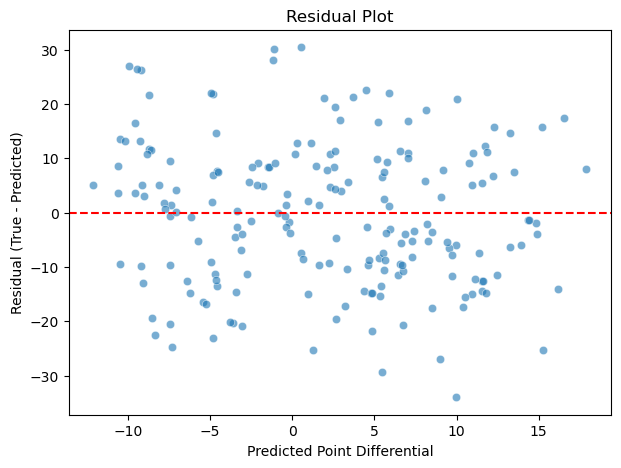

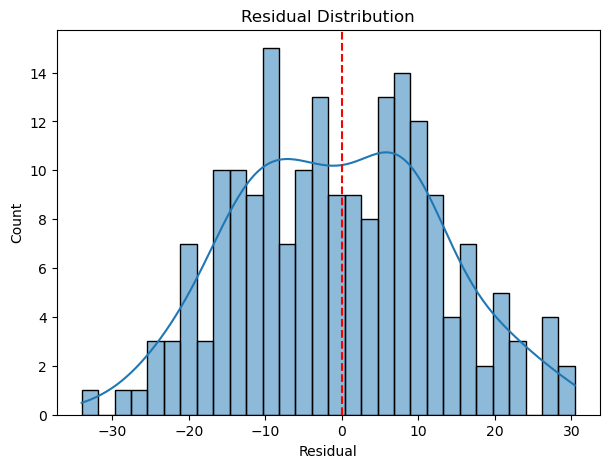

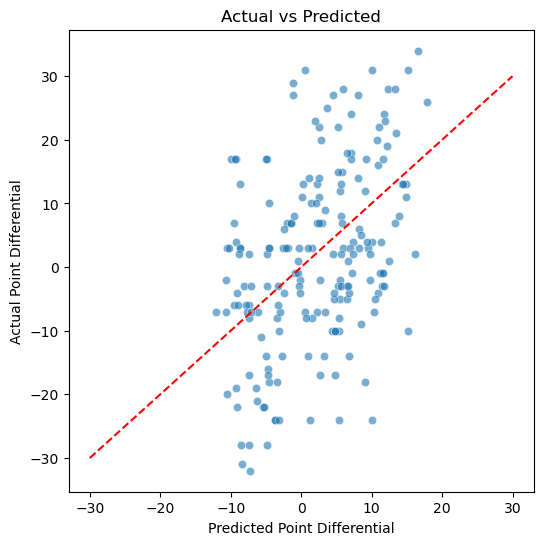

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

df23 = pd.read_csv("/Users/ryansteele/my_repo2/reports/predictions_test_2023.csv")
df24 = pd.read_csv("/Users/ryansteele/my_repo2/reports/predictions_test_2024.csv")
df25 = pd.read_csv("/Users/ryansteele/my_repo2/reports/predictions_test_2025.csv")

def plot_residuals(y_true, y_pred, title="Residual Plot"):
        residuals = y_true - y_pred
        
        plt.figure(figsize=(7,5))
        sns.scatterplot(x=y_pred, y=residuals, alpha=0.6)
        plt.axhline(0, color="red", linestyle="--")
        plt.xlabel("Predicted Point Differential")
        plt.ylabel("Residual (True - Predicted)")
        plt.title(title)
        plt.show()

def plot_residual_distribution(y_true, y_pred, title="Residual Distribution"):
    residuals = y_true - y_pred
    
    plt.figure(figsize=(7,5))
    sns.histplot(residuals, kde=True, bins=30)
    plt.axvline(0, color="red", linestyle="--")
    plt.xlabel("Residual")
    plt.title(title)
    plt.show()

def plot_actual_vs_pred(y_true, y_pred, title="Actual vs Predicted"):
    plt.figure(figsize=(6,6))
    sns.scatterplot(x=y_pred, y=y_true, alpha=0.6)
    plt.plot([-30, 30], [-30, 30], "--", color="red")  # ideal line
    plt.xlabel("Predicted Point Differential")
    plt.ylabel("Actual Point Differential")
    plt.title(title)
    plt.show()

dfs = [df23, df24, df25]
for df in dfs:
    y_true = df["y_true"]
    y_pred = df["y_pred"]
    print(df["season"][1])
    plot_residuals(y_true, y_pred)
    plot_residual_distribution(y_true, y_pred)
    plot_actual_vs_pred(y_true, y_pred)


### Residual Plots

Residual plots for all test seasons are broadly dispersed without any
apparent patterns. This indicates a good model fit and strong generalization
across test seasons.

### Residual Distributions

All residual distributions follow a normal distribution, which indicates low
bias. Distributions for test seasons 2024 and 2025 are slightly skewed right,
indicating that the model occasionally underpredicts blowouts. These are healthy
distributions and show strong generalization across test seasons.

### Actual vs. Predicted Scatter Plots

Scatter plots illustrate a strong, positive relationship between predicted
point differential and the true point differential. Each test season has
outliars (expected, blowouts/upsets are common), with 2025 test season having
a broader scatter than 2023 and 2024. This is most likely due to the fact that
the 2025 season is in progress so there is less data for season.

Found files: ['predictions_test_2023.csv', 'predictions_test_2024.csv', 'predictions_test_2025.csv']


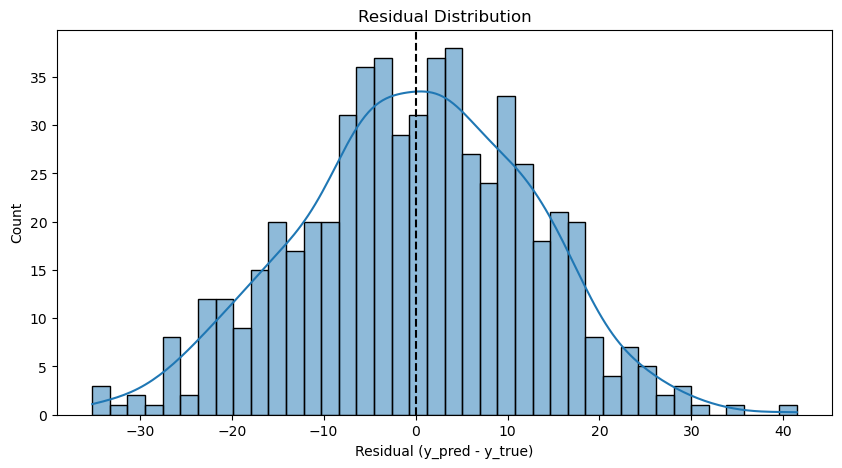

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

results_dir = Path("/Users/ryansteele/my_repo2/reports")

files_test = sorted(results_dir.glob("predictions_test_*.csv"))

print("Found files:", [f.name for f in files_test])

dfs = [pd.read_csv(f) for f in files_test]
df_test_all = pd.concat(dfs, ignore_index=True)
df_test_all = df_test_all.sort_values(["season", "week", "team"]).reset_index(drop=True)

df_test_all["residual"] = df_test_all["y_pred"] - df_test_all["y_true"]
df_test_all["abs_residual"] = df_test_all["residual"].abs()

plt.figure(figsize=(10,5))
sns.histplot(df_test_all["residual"], bins=40, kde=True)
plt.axvline(0, color="black", linestyle="--")
plt.title("Residual Distribution")
plt.xlabel("Residual (y_pred - y_true)")
plt.ylabel("Count")
plt.show()

### Residual Distribution Analysis

The residual distribution for all test seasons follows a normal
distribution, centered around zero, indicating little bias. Distribution is 
slightly skewed right, which again illustrates that the model occasionally 
underpredicts blowouts.

In [3]:
df_test_all["abs_residual"] = (df_test_all["y_pred"] - df_test_all["y_true"]).abs()

top10 = df_test_all.nlargest(10, "abs_residual")
top10[["season", "week", "team", "opponent", "y_true", "y_pred", "abs_residual"]]


,season,week,team,opponent,y_true,y_pred,abs_residual
197,2024,6,DAL,DET,-38.0,3.468586,41.468586
376,2024,18,DEN,KC,38.0,2.828907,35.171093
272,2024,11,DET,JAX,46.0,11.251164,34.748836
418,2025,8,ATL,MIA,-24.0,9.993690,33.993690
140,2023,15,LV,LAC,42.0,8.323626,33.676373
271,2024,11,DEN,ATL,32.0,-0.011548,32.011548
515,2025,14,MIN,WAS,31.0,0.545164,30.454836
64,2023,10,JAX,SF,-31.0,-0.582965,30.417035
464,2025,11,JAX,LAC,29.0,-1.089223,30.089223
209,2024,7,ATL,SEA,-20.0,9.954572,29.954572


### Error Analysis for 10 Largest Errors

All of the largest errors occur in huge wins, where the model often correctly 
identifies the winner but is off by a large magnitude. This is expected and 
speaks to the volatility of NFL games.

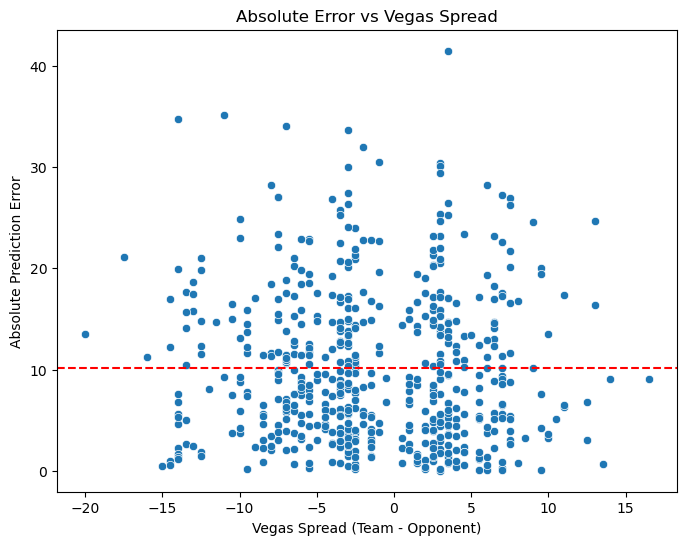

In [4]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df_test_all, x="vegas_spread", y="abs_residual")
plt.title("Absolute Error vs Vegas Spread")
plt.xlabel("Vegas Spread (Team - Opponent)")
plt.ylabel("Absolute Prediction Error")
plt.axhline(df_test_all["abs_residual"].mean(), color="red", linestyle="--")
plt.show()

### Absolute Error vs. Vegas Spread

This residual plot examines whether the model performs worse on bigger
vegas spreads. The plot shows no meaningful trend, indicating that Vegas
spreads are not indicative of model error. Therefore, the model is not 
disproportionally bad at predicting outcomes of games across Vegas spreads, with
high errors spread evenly. Most residuals cluster around the 5-15 point range,
indicating strong model performance.

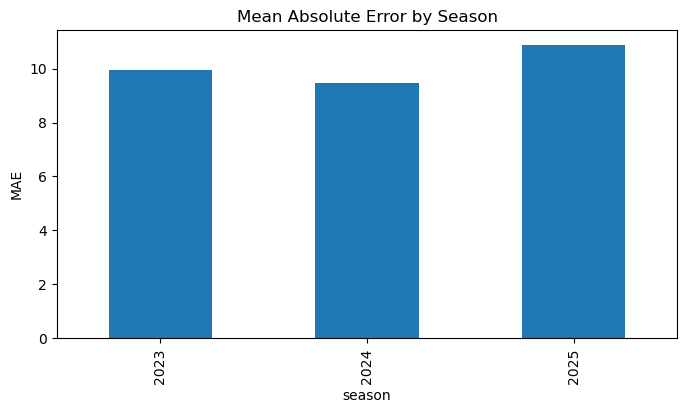

In [5]:
season_error = df_test_all.groupby("season")["abs_residual"].mean()

season_error.plot(kind="bar", figsize=(8,4), title="Mean Absolute Error by Season")
plt.ylabel("MAE")
plt.show()

### MAEs Across Test Seasons

Mean absolute errors across seasons 2023-2025 are relatively similar, 
indicating strong generalization across test seasons. 2024 was the best season
for mean absolute error, however, since rolling time-series splits are used
for train/val/test splits, 2025 mean absolute error will likely get better 
as more data becomes available for season.

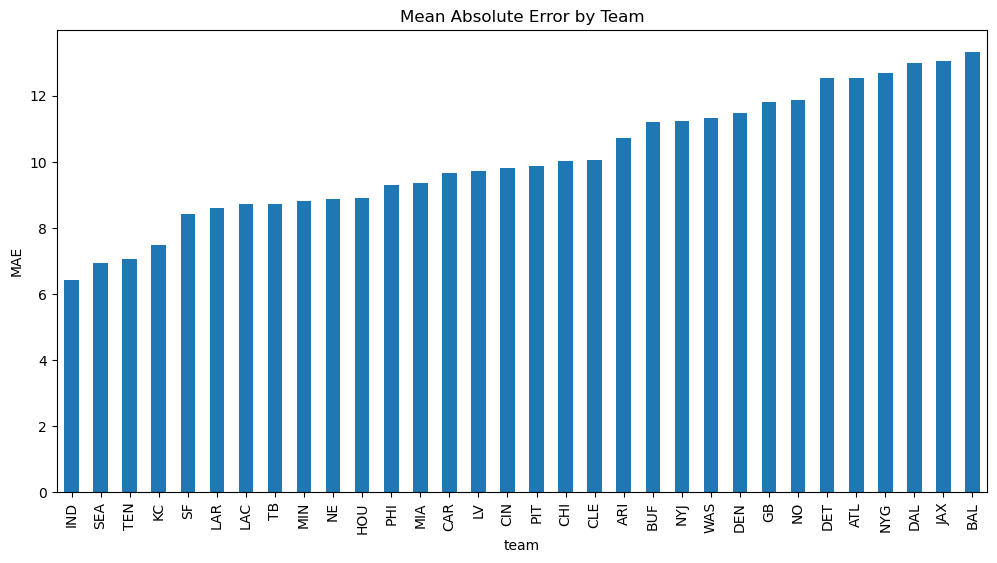

In [6]:
team_error = df_test_all.groupby("team")["abs_residual"].mean().sort_values()

team_error.plot(kind="bar", figsize=(12,6), title="Mean Absolute Error by Team")
plt.ylabel("MAE")
plt.show()

### MAE by Team

The mean absolute errors by team varies a bit, with some teams being less 
predictable than others. This is likely due to injuries and inconsistant
performance, with teams like NYG, WAS, DAL, and BAL having big injury-problems
in recent seasons. Other teams, such as KC, SEA, and PHI have performed 
similarly in each test season, likely contributing to lower mean absolute 
errors.

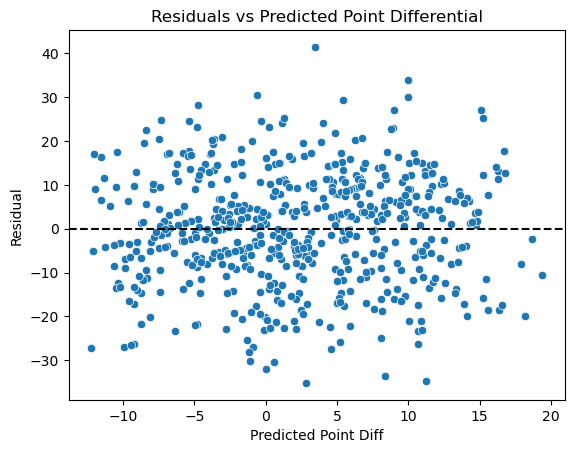

In [7]:
sns.scatterplot(x=df_test_all["y_pred"], y=df_test_all["residual"])
plt.axhline(0, color="black", linestyle="--")
plt.title("Residuals vs Predicted Point Differential")
plt.xlabel("Predicted Point Diff")
plt.ylabel("Residual")
plt.show()

### Residuals vs. Predicted Point Diff

The residual plot for predicted point differentials is spread evenly, without 
any apparent trend. This indicates that the model performs similarly across
magnitudes of predicted spreads.